In [ ]:
# === Cell 1: Import libraries and load data ===
# Rationale: Self-contained notebook — reload everything from scratch
# so anyone can run this independently.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Load and clean data
metadata = pd.read_csv('../data/metadata.csv', sep=';')
asv_table = pd.read_excel('../data/seqtab_nochim_export.xlsx')
asv_table = asv_table.rename(columns={'Unnamed: 0': 'SampleID'}).set_index('SampleID')
taxonomy = pd.read_excel('../data/taxa_species_export.xlsx')
taxonomy = taxonomy.rename(columns={'Unnamed: 0': 'ASV'}).set_index('ASV')

print(f"ASV table: {asv_table.shape[0]} samples x {asv_table.shape[1]} ASVs")
print(f"Disease groups: {dict(metadata['DiseaseStatus'].value_counts())}")

In [2]:
# === Cell 2: Feature preparation ===
# Rationale: We build four feature matrices at increasing resolution to show
# how classifier performance changes as we move from coarse to fine-grained features.
#   A. Phylum-level  (11 features)  — coarsest, already shown to lack signal
#   B. PCoA coordinates              — distance-based, same signal PERMANOVA found significant
#   C. ASV-level (rel. abundance)    — finest, captures taxon-specific shifts
#   D. ASV-level (CLR-transformed)   — same features but compositionally valid

from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

# --- Shared: relative abundance normalization + label encoding ---
asv_rel = asv_table.div(asv_table.sum(axis=1), axis=0)
meta = metadata.set_index('host_disease')[['DiseaseStatus']]

le = LabelEncoder()
y = le.fit_transform(meta.loc[asv_rel.index, 'DiseaseStatus'])
print(f"Classes: {list(le.classes_)}\n")

# --- A. Phylum-level (baseline) ---
phylum_map = taxonomy['Phylum'].dropna()
asv_classified = asv_rel[asv_rel.columns.intersection(phylum_map.index)]
phylum_counts = asv_classified.T.groupby(phylum_map).sum().T
phylum_rel = phylum_counts.div(phylum_counts.sum(axis=1), axis=0)
prevalence = (phylum_rel > 0).mean(axis=0)
X_phylum = phylum_rel.loc[:, prevalence >= 0.10].values

# --- B. PCoA coordinates (Bray-Curtis) ---
bc_dm = beta_diversity('braycurtis', asv_rel.values, ids=asv_rel.index)
pcoa_results = pcoa(bc_dm)
explained = pcoa_results.proportion_explained.cumsum()
n_axes = int((explained < 0.90).sum()) + 1  # axes needed for ≥90% variance
X_pcoa = pcoa_results.samples.iloc[:, :n_axes].values
print(f"PCoA: using {n_axes} axes ({explained.iloc[n_axes-1]*100:.1f}% variance explained)")

# --- C. ASV-level (relative abundance) ---
prevalence_asv = (asv_rel > 0).mean(axis=0)
asv_prevalent = asv_rel.loc[:, prevalence_asv >= 0.10].values
X_asv = asv_prevalent

# --- D. ASV-level (CLR-transformed) ---
# Microbiome data is compositional: values sum to 1, creating spurious correlations.
# CLR maps the simplex to Euclidean space, making linear models geometrically valid.
# CLR(x_i) = log(x_i + δ) - mean(log(x_j + δ))  for all j in the sample.
# Pseudocount δ=1e-6 handles structural zeros from sequencing.
delta = 1e-6
log_asv = np.log(asv_prevalent + delta)
X_asv_clr = log_asv - log_asv.mean(axis=1, keepdims=True)

print(f"\nFeature matrix shapes:")
print(f"  A. Phylum-level        : {X_phylum.shape}")
print(f"  B. PCoA coords         : {X_pcoa.shape}")
print(f"  C. ASV-level (rel. ab) : {X_asv.shape}")
print(f"  D. ASV-level (CLR)     : {X_asv_clr.shape}")
print(f"  Target (y)             : {y.shape}")

Classes: ['Adenomatous Polyps', 'Colorectal cancer', 'Healthy']

PCoA: using 34 axes (90.6% variance explained)

Feature matrix shapes:
  A. Phylum-level        : (59, 11)
  B. PCoA coords         : (59, 34)
  C. ASV-level (rel. ab) : (59, 1045)
  D. ASV-level (CLR)     : (59, 1045)
  Target (y)             : (59,)


In [3]:
# === Cell 3: Cross-validated classification across all four feature sets ===
# Rationale: RepeatedStratifiedKFold (5 folds × 50 repeats = 250 rounds per model)
# gives stable estimates on this small dataset (n=59).
# LR and SVM are wrapped in a Pipeline with StandardScaler: each feature is scaled
# to mean=0, std=1 on the training fold and applied to the test fold (no data leakage).
# RF and XGBoost are tree-based and scale-invariant — no scaling needed.
# F1-weighted accounts for the slight class imbalance (19/19/21 samples).

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=500, random_state=42),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                     ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'SVM'                : Pipeline([('scaler', StandardScaler()),
                                     ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
    'XGBoost'            : XGBClassifier(n_estimators=200, eval_metric='mlogloss', random_state=42),
}

feature_sets = {
    'Phylum'  : X_phylum,
    'PCoA'    : X_pcoa,
    'ASV'     : X_asv,
    'ASV (CLR)': X_asv_clr,
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=30, random_state=42)
results = {}  # {(feature_set, model): {'accuracy': ..., 'f1': ...}}

for fs_name, X in feature_sets.items():
    print(f"\n=== Feature set: {fs_name} ===")
    for model_name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv,
                                scoring=['accuracy', 'f1_weighted'],
                                n_jobs=-1)
        acc     = scores['test_accuracy'].mean()
        acc_std = scores['test_accuracy'].std()
        f1      = scores['test_f1_weighted'].mean()
        f1_std  = scores['test_f1_weighted'].std()
        results[(fs_name, model_name)] = {'accuracy': acc, 'f1': f1}
        print(f"  {model_name:22s}  Acc={acc:.3f}±{acc_std:.3f}  F1={f1:.3f}±{f1_std:.3f}")


=== Feature set: Phylum ===
  Random Forest           Acc=0.372±0.137  F1=0.356±0.142
  Logistic Regression     Acc=0.397±0.123  F1=0.373±0.130
  SVM                     Acc=0.366±0.119  F1=0.337±0.129
  XGBoost                 Acc=0.369±0.138  F1=0.349±0.143

=== Feature set: PCoA ===
  Random Forest           Acc=0.616±0.125  F1=0.608±0.129
  Logistic Regression     Acc=0.589±0.129  F1=0.580±0.138
  SVM                     Acc=0.620±0.118  F1=0.595±0.138
  XGBoost                 Acc=0.572±0.118  F1=0.558±0.126

=== Feature set: ASV ===
  Random Forest           Acc=0.594±0.123  F1=0.582±0.127
  Logistic Regression     Acc=0.629±0.131  F1=0.623±0.133
  SVM                     Acc=0.593±0.123  F1=0.560±0.140
  XGBoost                 Acc=0.601±0.125  F1=0.590±0.128

=== Feature set: ASV (CLR) ===
  Random Forest           Acc=0.515±0.139  F1=0.506±0.145
  Logistic Regression     Acc=0.678±0.115  F1=0.673±0.119
  SVM                     Acc=0.609±0.126  F1=0.596±0.131
  XGBoost       

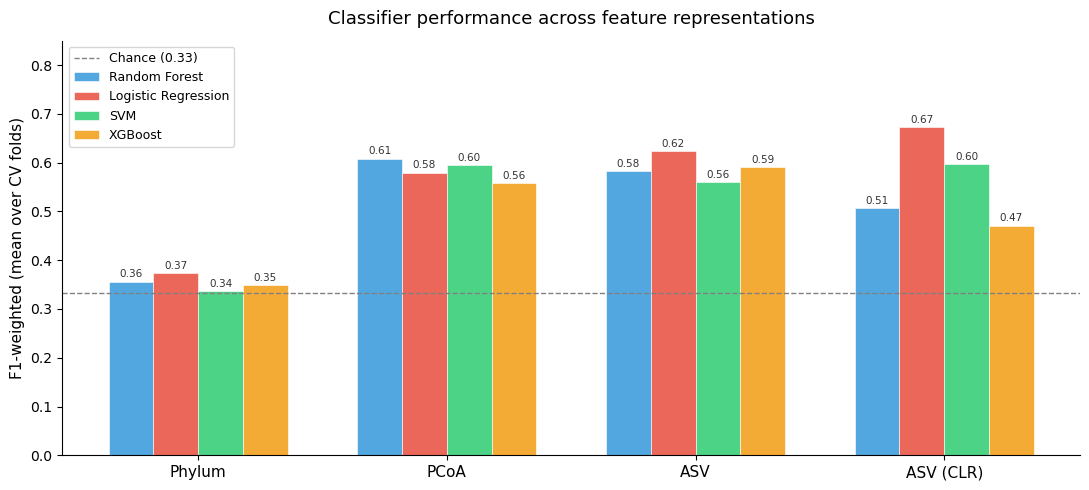

Saved: ../figures/05_model_comparison.png


In [4]:
# === Cell 4: Model comparison plot ===
# Grouped bar chart: F1-weighted for all 4 models × 4 feature sets.
# Reading left to right shows the performance progression as feature resolution increases:
# Phylum (chance-level) → PCoA → ASV (rel. ab.) → ASV (CLR).

feature_order = ['Phylum', 'PCoA', 'ASV', 'ASV (CLR)']
model_order   = list(models.keys())
model_colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

n_fs     = len(feature_order)
n_models = len(model_order)
bar_w    = 0.18
x        = np.arange(n_fs)

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model_name, color) in enumerate(zip(model_order, model_colors)):
    f1_vals = [results[(fs, model_name)]['f1'] for fs in feature_order]
    offset  = (i - n_models / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, f1_vals, width=bar_w, label=model_name,
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, color='#333333')

# Chance-level reference line (3 classes → 1/3)
ax.axhline(1/3, color='grey', linestyle='--', linewidth=1, label='Chance (0.33)')

ax.set_xticks(x)
ax.set_xticklabels(feature_order, fontsize=11)
ax.set_ylabel('F1-weighted (mean over CV folds)', fontsize=11)
ax.set_title('Classifier performance across feature representations', fontsize=13, pad=12)
ax.set_ylim(0, 0.85)
ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/05_model_comparison.png")

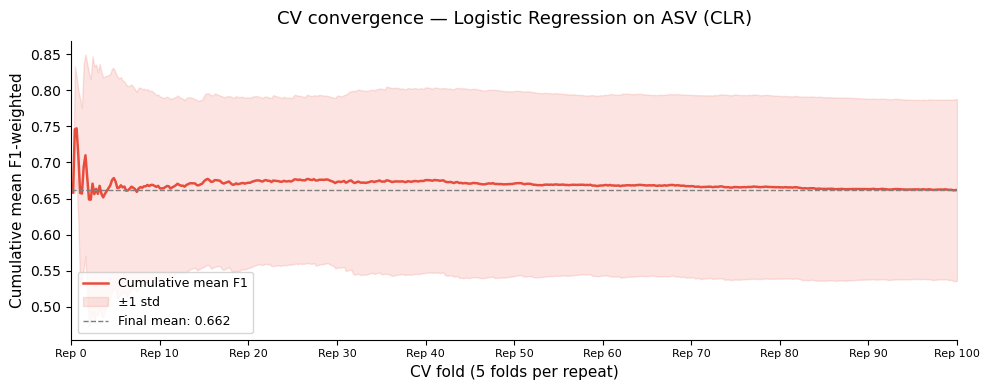

Final F1 (mean ± std over 100 repeats × 5 folds): 0.662 ± 0.126


In [5]:
# === Cell 5: CV convergence plot — Logistic Regression on ASV (CLR) ===
# Each CV repeat produces 5 fold scores. Plotting the cumulative mean after every fold
# shows how many repeats are needed before the estimate stabilises.
# A tight, flat curve = the estimate has converged; a wobbly curve = more repeats needed.

best_model = Pipeline([('scaler', StandardScaler()),
                        ('clf', LogisticRegression(max_iter=1000, random_state=42))])

# Run with enough repeats to show the convergence story clearly
n_repeats_conv = 100
cv_conv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats_conv, random_state=42)

conv_scores = cross_validate(best_model, X_asv_clr, y, cv=cv_conv,
                              scoring='f1_weighted', n_jobs=-1)
fold_f1 = conv_scores['test_score']          # shape: (n_splits * n_repeats_conv,)
cum_mean = np.cumsum(fold_f1) / np.arange(1, len(fold_f1) + 1)
cum_std  = np.array([fold_f1[:i+1].std() for i in range(len(fold_f1))])

# X-axis: repeat number (each repeat = n_splits folds)
n_folds_total = len(fold_f1)
fold_idx      = np.arange(1, n_folds_total + 1)
repeat_ticks  = np.arange(0, n_repeats_conv + 1, 10) * 5  # every 10 repeats

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(fold_idx, cum_mean, color='#e74c3c', linewidth=1.8, label='Cumulative mean F1')
ax.fill_between(fold_idx,
                cum_mean - cum_std,
                cum_mean + cum_std,
                alpha=0.15, color='#e74c3c', label='±1 std')
ax.axhline(cum_mean[-1], color='grey', linestyle='--', linewidth=1,
           label=f'Final mean: {cum_mean[-1]:.3f}')

ax.set_xlabel('CV fold (5 folds per repeat)', fontsize=11)
ax.set_ylabel('Cumulative mean F1-weighted', fontsize=11)
ax.set_title('CV convergence — Logistic Regression on ASV (CLR)', fontsize=13, pad=12)
ax.set_xlim(1, n_folds_total)
ax.set_xticks(repeat_ticks)
ax.set_xticklabels([f'Rep {t//5}' for t in repeat_ticks], fontsize=8)
ax.legend(fontsize=9, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/05_cv_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Final F1 (mean ± std over {n_repeats_conv} repeats × 5 folds): "
      f"{cum_mean[-1]:.3f} ± {fold_f1.std():.3f}")

=== Convergence check (max_iter=1000) ===
  Converged within 1000 iterations — max_iter is not a bottleneck.

=== Regularization sweep (C parameter) ===
  C=  0.001  F1=0.628 ± 0.133
  C=   0.01  F1=0.665 ± 0.124
  C=    0.1  F1=0.674 ± 0.119
  C=    0.5  F1=0.674 ± 0.120
  C=    1.0  F1=0.673 ± 0.119
  C=    5.0  F1=0.672 ± 0.122
  C=   10.0  F1=0.674 ± 0.127
  C=  100.0  F1=0.677 ± 0.124

Best C: 100.0  (F1=0.677)


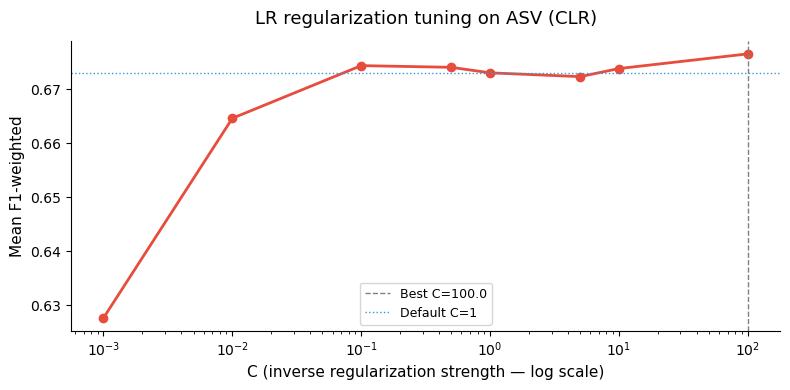

Saved: ../figures/05_regularization_tuning.png


In [6]:
# === Cell 6: Convergence check + regularization tuning (C parameter) ===
# Step 1: Check if LR actually converges within max_iter=1000.
# Step 2: Search over C values — C controls regularization strength (smaller C = stronger).
#         With 1045 features and only 59 samples (p >> n), the default C=1 may overfit.

import warnings

# --- Step 1: Convergence check ---
print("=== Convergence check (max_iter=1000) ===")
try:
    with warnings.catch_warnings():
        warnings.filterwarnings('error')
        lr_check = Pipeline([('scaler', StandardScaler()),
                              ('clf', LogisticRegression(max_iter=1000, random_state=42))])
        lr_check.fit(X_asv_clr, y)
    print("  Converged within 1000 iterations — max_iter is not a bottleneck.\n")
except Exception as e:
    print(f"  ConvergenceWarning raised: {e}")
    print("  Consider increasing max_iter or switching solver.\n")

# --- Step 2: Tune C ---
# C is the inverse of regularization strength: C=0.001 (very constrained) → C=100 (near-unconstrained).
# We sweep on a log scale and use the same CV setup as Cell 3 for a fair comparison.
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 100.0]
cv_tune  = RepeatedStratifiedKFold(n_splits=5, n_repeats=30, random_state=42)

print("=== Regularization sweep (C parameter) ===")
c_results = {}
for C in C_values:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('clf', LogisticRegression(C=C, max_iter=2000, random_state=42))])
    scores = cross_validate(pipe, X_asv_clr, y, cv=cv_tune,
                            scoring='f1_weighted', n_jobs=-1)
    mean_f1 = scores['test_score'].mean()
    std_f1  = scores['test_score'].std()
    c_results[C] = mean_f1
    print(f"  C={C:>7}  F1={mean_f1:.3f} ± {std_f1:.3f}")

best_C  = max(c_results, key=c_results.get)
best_f1 = c_results[best_C]
print(f"\nBest C: {best_C}  (F1={best_f1:.3f})")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, [c_results[c] for c in C_values],
            marker='o', color='#e74c3c', linewidth=2, markersize=6)
ax.axvline(best_C, color='grey', linestyle='--', linewidth=1, label=f'Best C={best_C}')
ax.axhline(c_results[1.0], color='#3498db', linestyle=':', linewidth=1, label='Default C=1')
ax.set_xlabel('C (inverse regularization strength — log scale)', fontsize=11)
ax.set_ylabel('Mean F1-weighted', fontsize=11)
ax.set_title('LR regularization tuning on ASV (CLR)', fontsize=13, pad=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/05_regularization_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/05_regularization_tuning.png")

Converged at iteration 18  (loss=0.004438)


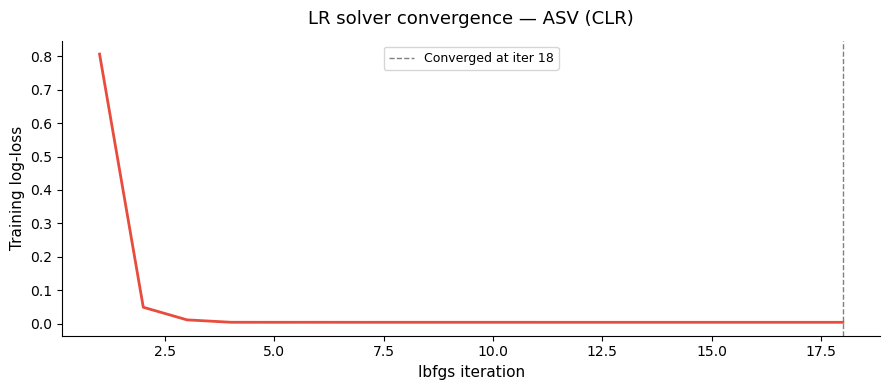

Saved: ../figures/05_lr_convergence.png


In [7]:
# === Cell 7: LR solver convergence curve ===
# warm_start=True tells sklearn to continue from the previous weights instead of
# restarting. By incrementing max_iter by 1 each call, we run exactly one lbfgs
# step at a time and record the training loss after each step.
# Note: this is *training* loss (how well the model fits the 59 samples),
# not generalisation performance — we're watching the optimiser work.

from sklearn.metrics import log_loss as compute_log_loss

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_asv_clr)

# tol=1e-12: near-zero tolerance so the solver never stops early due to gradient size;
# we want to trace the full path and detect convergence from the loss curve itself.
lr_trace = LogisticRegression(warm_start=True, tol=1e-12,
                               solver='lbfgs', random_state=42)
losses = []

for n_iter in range(1, 500):
    lr_trace.max_iter = n_iter
    lr_trace.fit(X_scaled, y)
    proba = lr_trace.predict_proba(X_scaled)
    losses.append(compute_log_loss(y, proba))

    # Stop when loss improvement drops below 1e-8 — the solver has effectively converged
    if len(losses) > 5 and abs(losses[-2] - losses[-1]) < 1e-8:
        converged_at = n_iter
        print(f"Converged at iteration {converged_at}  (loss={losses[-1]:.6f})")
        break

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(losses) + 1), losses, color='#e74c3c', linewidth=2)
ax.axvline(converged_at, color='grey', linestyle='--', linewidth=1,
           label=f'Converged at iter {converged_at}')
ax.set_xlabel('lbfgs iteration', fontsize=11)
ax.set_ylabel('Training log-loss', fontsize=11)
ax.set_title('LR solver convergence — ASV (CLR)', fontsize=13, pad=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/05_lr_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/05_lr_convergence.png")